In [32]:
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

In [33]:
path = '/scratch/user/perry5334/samples/DMC_SNOLAB_HV/CUTE_Cf252calib_source/DMCOutput_EmptyEvents_Spectrum/'
DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))
det = 1

In [34]:
mczipFrame = CDataFrame(f"G4SimDir/mczip{det}", DMCfiles)
mczip = mczipFrame.AsNumpy(['EventNum', 'PName', 'Edep', 'Parent', 'Track', 'Time1', 'Time3', 'VolName'])
mcDecaysFrame = CDataFrame("G4SimDir/mcDecays", DMCfiles)
mcDecays = mcDecaysFrame.Filter(f'DetNum=={det}').AsNumpy(['EventNum', 'PName', 'KE', 'Parent', 'Track', 'Time1', 'Time3', 'VolName'])
#mceventFrame = CDataFrame(f"G4SimDir/mcevent", DMCfiles)
#mcevent = mceventFrame.AsNumpy(['EventNum', 'ZipsHit'])

# Save array of events where neutron capture and Ge71 activation occurred. Determined by recoil/decay of Ga71 nucleus.
GeActivEvents = np.unique(mczipFrame.Filter('string(PName.data()) == "Ga71"').AsNumpy(['EventNum'])['EventNum'])
#GeActivEventsmcDecays = np.unique(mcDecaysFrame.Filter(f'DetNum=={det}').Filter('string(PName.data()) == "Ga71"').AsNumpy(['EventNum'])['EventNum'])

runtime_error: string ROOT::RDF::RInterfaceBase::GetColumnType(basic_string_view<char,char_traits<char> > column) =>
    runtime_error: Column "VolName" is not in a dataset and is not a custom column been defined.

In [4]:
# Select events in mczip and mcDecays which correspond to Ge activation
mcDecaysEventMask = np.isin(mcDecays['EventNum'], GeActivEvents)
mczipEventMask = np.isin(mczip['EventNum'], GeActivEvents)

# Process Ge activation data from mcDecays tree
for key in list(mcDecays.keys()):
    mcDecays[key] = mcDecays[key][mcDecaysEventMask]

mcDecays['KEsum'] = np.array([mcDecays['KE'][mcDecays['EventNum'] == event].sum() for event in GeActivEvents])

# Process Ge activation data from mczip tree
for key in list(mczip.keys()):
    mczip[key] = mczip[key][mczipEventMask]

mczip['Edepsum'] = np.array([mczip['Edep'][mczip['EventNum'] == event].sum() for event in GeActivEvents])

In [17]:
mcDecaysTimeCut = (mcDecays['Time1'] < 5e16) & (mcDecays['Time1'] > 5e10)
mczipTimeCut = (mczip['Time1'] < 5e16) & (mczip['Time1'] > 5e10)
mcDecays['KEsum'] = np.array([mcDecays['KE'][(mcDecays['EventNum'] == event) & mcDecaysTimeCut].sum() for event in GeActivEvents])
mczip['Edepsum'] = np.array([mczip['Edep'][(mczip['EventNum'] == event) & mczipTimeCut].sum() for event in GeActivEvents])

(0.5882347977301472, 50000000.0)

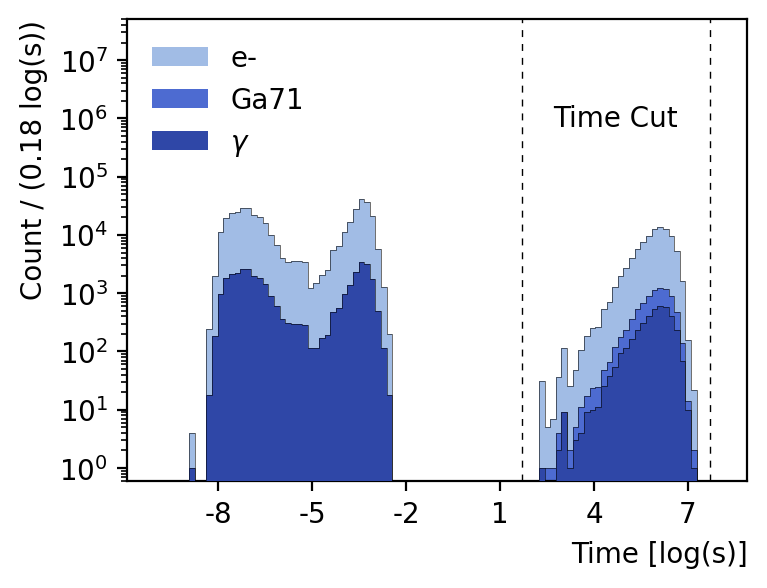

In [6]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Time1'][mczip['PName'] == 'e-']*1e-9, bins = np.logspace(-10,8, 101), zorder = 0, label = 'e-', color = 'C0')
plt.hist(mczip['Time1'][mczip['PName'] == 'e-']*1e-9, bins = np.logspace(-10,8, 101), histtype='step', color = 'black', lw = 0.2, zorder = 1)
plt.hist(mczip['Time1'][mczip['PName'] == 'Ga71']*1e-9, bins = np.logspace(-10,8, 101), zorder = 2, label = 'Ga71', color = 'C1')
plt.hist(mczip['Time1'][mczip['PName'] == 'Ga71']*1e-9, bins = np.logspace(-10,8, 101), histtype='step', color = 'black', lw = 0.2, zorder = 3)
plt.hist(mczip['Time1'][mczip['PName'] == 'gamma']*1e-9, bins = np.logspace(-10,8, 101), zorder = 4, label = r'$\gamma$', color = 'C2')
plt.hist(mczip['Time1'][mczip['PName'] == 'gamma']*1e-9, bins = np.logspace(-10,8, 101), histtype='step', color = 'black', lw = 0.2, zorder = 5)

plt.axvline(5e1, 0, 1, lw = 0.5, ls = (0, (5, 5)), color = 'black')
plt.axvline(5e7, 0, 1, lw = 0.5, ls = (0, (5, 5)), color = 'black')
plt.text(5e4, 1e6, 'Time Cut', ha = 'center', va = 'center', fontstretch='extra-expanded', weight = 550)

plt.xlabel('Time [log(s)]')
plt.ylabel('Count / (0.18 log(s))')
plt.xscale('log')
plt.xticks([1e-8, 1e-5, 1e-2, 1e1, 1e4, 1e7], ['-8', '-5', '-2', '1', '4', '7'])
plt.yscale('log')
plt.legend(loc = 'upper left')
plt.ylim(None, 5e7)

Text(0, 1, 'Count / (0.24 keV)')

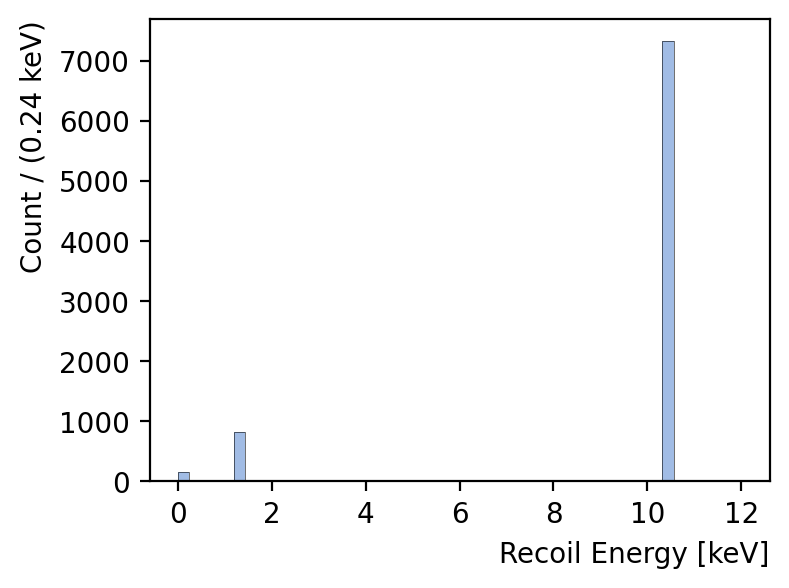

In [7]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Edepsum']*1e-3, np.linspace(0, 12, 51), alpha = 1, color = 'C0')
plt.hist(mczip['Edepsum']*1e-3, np.linspace(0, 12, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Recoil Energy [keV]')
plt.ylabel('Count / (0.24 keV)')

Text(0, 1, 'Count / (0.24 keV)')

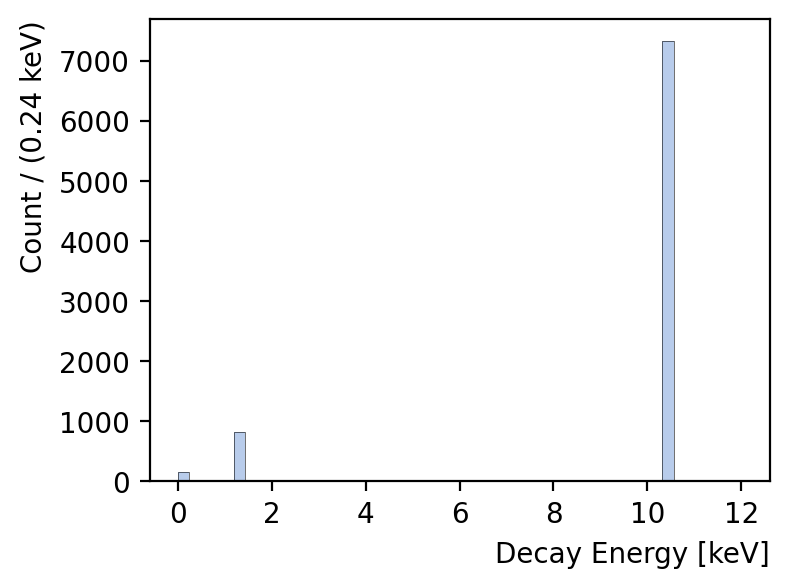

In [8]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 51), alpha = 0.75)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.24 keV)')

In [26]:
event = mczip['Edepsum'].tolist().index(max(mczip['Edepsum']))

In [27]:
mczip['PName'][(mczip['EventNum'] == GeActivEvents[event]) & mczipTimeCut]

ndarray(['Ga71', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'gamma',
         'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-',
         'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-',
         'e-'], dtype='<U14')

In [28]:
mcDecays['PName'][(mcDecays['EventNum'] == GeActivEvents[event]) & mcDecaysTimeCut]

ndarray(['e-', 'Ga71'], dtype='<U15')

In [29]:
mcDecays['KE'][(mcDecays['EventNum'] == GeActivEvents[event]) & mcDecaysTimeCut]

ndarray([1.72446147e+06, 2.18338682e+01])

In [30]:
mcDecays['Parent'][(mcDecays['EventNum'] == GeActivEvents[event]) & mcDecaysTimeCut]

ndarray([4., 4.])

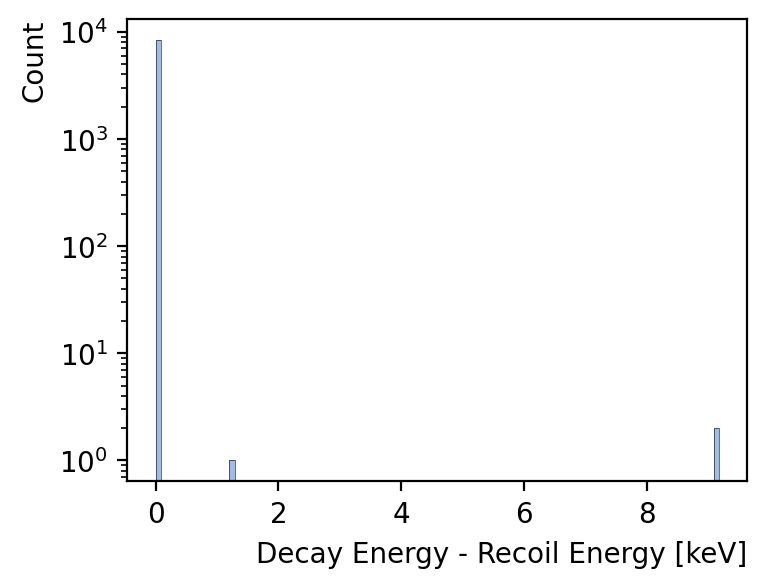

In [31]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist((mcDecays['KEsum']-mczip['Edepsum'])*1e-3, bins = 100, alpha = 1)
plt.hist((mcDecays['KEsum']-mczip['Edepsum'])*1e-3, bins = 100, histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy - Recoil Energy [keV]')
plt.ylabel('Count')
plt.yscale('log')

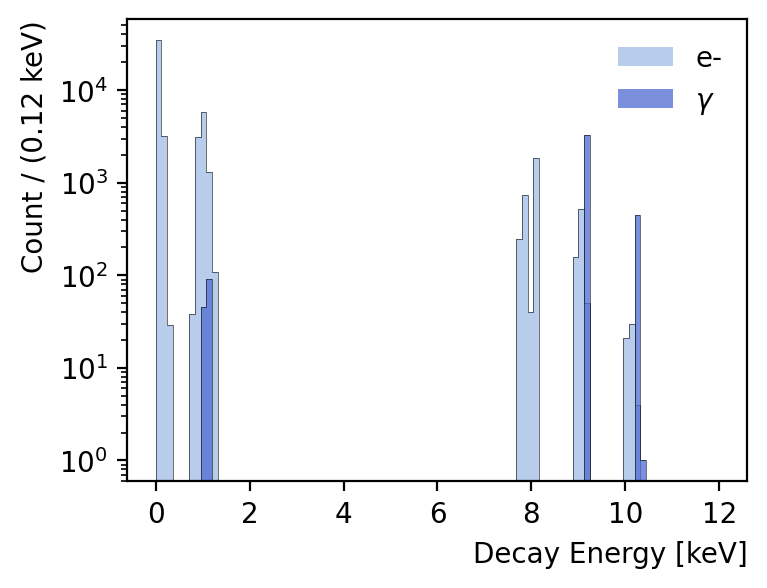

In [170]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'e-']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75, zorder = 0, label = 'e-', color = 'C0')
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'e-']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, zorder = 1)
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'gamma']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75, zorder = 2, label = r'$\gamma$', color = 'C1')
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'gamma']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, zorder = 3)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.12 keV)')
plt.yscale('log')
plt.legend()